# Proyecto AUDIO - Parte 2: ML Clásico y DL From Scratch
## Análisis de Datos No Estructurados 2025-2026

**Dataset:** ATCOSIM Corpus  
**Objetivo:** Clasificación de comunicaciones ATC usando ML y DL from scratch

---

## Pipeline:

1. **Feature Engineering** - Extracción completa de features (MFCCs, spectral)
2. **Machine Learning Clásico** - SVM, Random Forest (baseline)
3. **Deep Learning From Scratch** - CNN 1D/2D para clasificación
4. **Análisis de Overfitting** - Curvas de accuracy/loss, confusion matrix
5. **Comparación de modelos** - Conclusiones críticas

---

## 1. Importar Librerías y Cargar Datos Procesados

In [1]:
from pathlib import Path
NOTEBOOK_OUTPUT_DIR = Path("outputs") / "ADNE_Proyecto_Audio_Part2_ML_DL"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {NOTEBOOK_OUTPUT_DIR.resolve()}")

import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_recall_fscore_support
 )

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Output directory: /Users/pablomoreno/Desktop/ANALISIS/Proyecto_ATC_Comunicaciones_Aeronauticas/outputs/ADNE_Proyecto_Audio_Part2_ML_DL
Using device: cpu
PyTorch version: 2.10.0


##  2. Cargar Dataset ATCOSIM

In [2]:
print("Cargando dataset ATCOSIM...")
ds = load_dataset("Jzuluaga/atcosim_corpus")

train_data = ds['train'] if 'train' in ds else ds[list(ds.keys())[0]]

print(f"Dataset cargado: {len(train_data)} muestras")
print(f"Campos: {train_data.features.keys()}")

Cargando dataset ATCOSIM...
Dataset cargado: 7638 muestras
Campos: dict_keys(['id', 'audio', 'text', 'segment_start_time', 'segment_end_time', 'duration'])


##  3. Crear Categorías ATC (Labels)

Vamos a categorizar las comunicaciones ATC en:
- **takeoff**: Instrucciones de despegue
- **landing**: Instrucciones de aterrizaje
- **routing**: Cambios de altitud/rumbo
- **readback**: Confirmaciones
- **holding**: Esperas
- **frequency_change**: Cambios de frecuencia
- **other**: Otros

️Creando labels...


Categorizando: 100%|██████████| 7638/7638 [01:09<00:00, 110.33it/s]



Creados 7638 labels

Distribución de clases:
routing             3041
other               2243
frequency_change    1896
readback             310
landing              135
holding               13
Name: count, dtype: int64


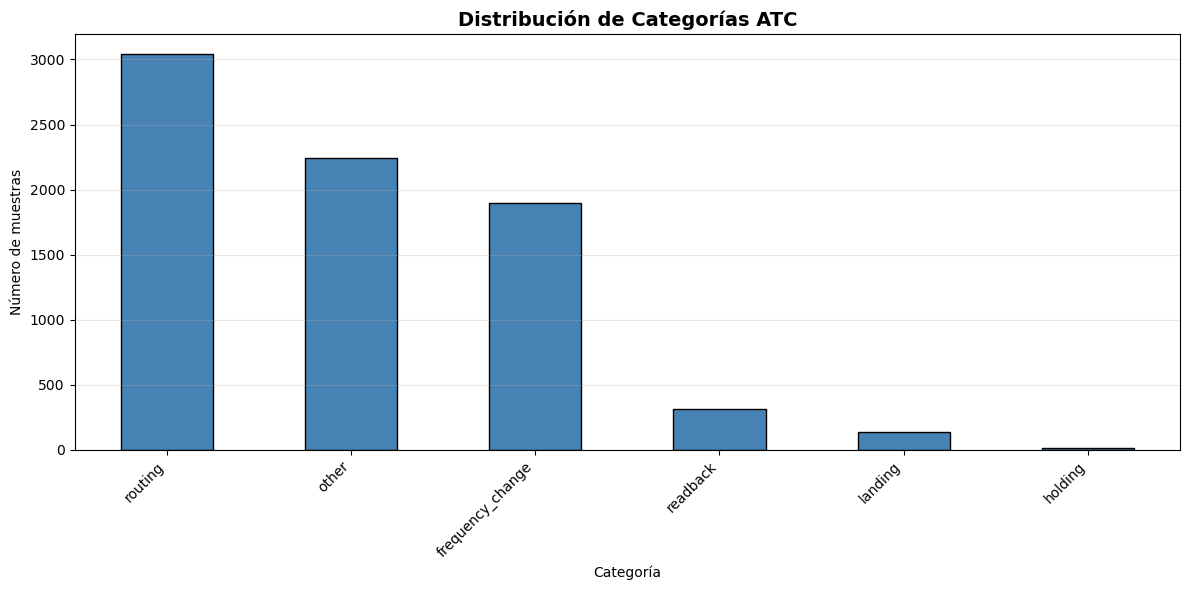

In [3]:
def categorize_atc_message(text):
    """
    Categoriza mensajes ATC basándose en palabras clave
    """
    if not isinstance(text, str) or text == '':
        return 'other'
    
    text_lower = text.lower()
    
    if any(word in text_lower for word in ['takeoff', 'take off', 'cleared for takeoff', 'departure', 'line up']):
        return 'takeoff'
    elif any(word in text_lower for word in ['landing', 'land', 'cleared to land', 'approach', 'final', 'runway']):
        return 'landing'
    elif any(word in text_lower for word in ['climb', 'descend', 'altitude', 'flight level', 'heading', 'turn', 'direct']):
        return 'routing'
    elif any(word in text_lower for word in ['roger', 'wilco', 'affirm', 'negative', 'correct', 'read back']):
        return 'readback'
    elif any(word in text_lower for word in ['hold', 'holding', 'wait', 'standby']):
        return 'holding'
    elif any(word in text_lower for word in ['contact', 'frequency', 'squawk']):
        return 'frequency_change'
    else:
        return 'other'

print("️Creando labels...")
labels = []
valid_indices = []

for i in tqdm(range(len(train_data)), desc="Categorizando"):
    text = ""
    for possible_key in ['text', 'transcript', 'transcription']:
        if possible_key in train_data[i]:
            text = str(train_data[i][possible_key])
            break
    
    if text:
        label = categorize_atc_message(text)
        labels.append(label)
        valid_indices.append(i)

print(f"\nCreados {len(labels)} labels")

label_counts = pd.Series(labels).value_counts()
print("\nDistribución de clases:")
print(label_counts)

plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribución de Categorías ATC', fontsize=14, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Número de muestras')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

##  4. FEATURE ENGINEERING - Extracción Completa de Features

Extraemos features de audio para **TODAS** las muestras:
- **MFCCs** (13 coeficientes)
- **Spectral Centroid**
- **Spectral Rolloff**
- **Spectral Bandwidth**
- **Zero Crossing Rate**
- **Chroma Features**
- **RMS Energy**

In [4]:
def extract_audio_features(audio_dict, n_mfcc=13):
    """
    Extrae features completos de un audio
    Retorna un vector de features concatenado
    """
    try:
        audio_array = np.array(audio_dict['array'], dtype=np.float32)
        sr = audio_dict['sampling_rate']
        
        mfccs = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfccs, axis=1)
        mfcc_std = np.std(mfccs, axis=1)
        
        spectral_centroid = librosa.feature.spectral_centroid(y=audio_array, sr=sr)
        sc_mean = np.mean(spectral_centroid)
        sc_std = np.std(spectral_centroid)
        
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_array, sr=sr)
        sr_mean = np.mean(spectral_rolloff)
        sr_std = np.std(spectral_rolloff)
        
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio_array, sr=sr)
        sb_mean = np.mean(spectral_bandwidth)
        sb_std = np.std(spectral_bandwidth)
        
        zcr = librosa.feature.zero_crossing_rate(audio_array)
        zcr_mean = np.mean(zcr)
        zcr_std = np.std(zcr)
        
        chroma = librosa.feature.chroma_stft(y=audio_array, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_std = np.std(chroma, axis=1)
        
        rms = librosa.feature.rms(y=audio_array)
        rms_mean = np.mean(rms)
        rms_std = np.std(rms)
        
        features = np.concatenate([
            mfcc_mean, mfcc_std,
            [sc_mean, sc_std, sr_mean, sr_std, sb_mean, sb_std],
            [zcr_mean, zcr_std],
            chroma_mean, chroma_std,
            [rms_mean, rms_std]
        ])
        
        return features
        
    except Exception as e:
        print(f"Error extracting features: {e}")
        return None

print("Extrayendo features de audio...")
print("️Esto puede tardar varios minutos...\n")

X_features = []
y_labels = []

for i in tqdm(valid_indices[:2000], desc="Extrayendo features"):  # Limitamos a 2000 para rapidez
    audio_dict = train_data[i]['audio']
    features = extract_audio_features(audio_dict)
    
    if features is not None:
        X_features.append(features)
        y_labels.append(labels[valid_indices.index(i)])

X_features = np.array(X_features)
y_labels = np.array(y_labels)

print(f"\nFeatures extraídos:")
print(f"   Shape de X: {X_features.shape}")
print(f"   Shape de y: {y_labels.shape}")
print(f"   Número de features por muestra: {X_features.shape[1]}")

Extrayendo features de audio...
️Esto puede tardar varios minutos...



Extrayendo features: 100%|██████████| 2000/2000 [00:53<00:00, 37.52it/s]


Features extraídos:
   Shape de X: (2000, 60)
   Shape de y: (2000,)
   Número de features por muestra: 60


##  5. Preparación de Datos - Train/Val/Test Split

In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

print(f"Clases originales: {label_encoder.classes_}")
print(f"Número de clases originales: {len(label_encoder.classes_)}")

class_counts = pd.Series(y_encoded).value_counts().sort_index()
min_samples_per_class = 4
valid_classes = class_counts[class_counts >= min_samples_per_class].index

if len(valid_classes) < len(class_counts):
    removed_classes = class_counts[class_counts < min_samples_per_class].index
    removed_class_names = label_encoder.inverse_transform(removed_classes)
    print("\n️Clases con muy pocas muestras para stratify (se excluyen):")
    for cls_idx, cls_name in zip(removed_classes, removed_class_names):
        print(f"   - {cls_name}: {class_counts.loc[cls_idx]} muestra(s)")

mask = np.isin(y_encoded, valid_classes)
X_features_filtered = X_features[mask]
y_labels_filtered = y_labels[mask]

label_encoder = LabelEncoder()
y_encoded_filtered = label_encoder.fit_transform(y_labels_filtered)
all_class_labels = np.arange(len(label_encoder.classes_))

print(f"\nMuestras tras filtrado: {len(y_encoded_filtered)} / {len(y_encoded)}")
print(f"Clases activas tras filtrado: {label_encoder.classes_}")
print(f"Número de clases activas: {len(label_encoder.classes_)}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_features_filtered, y_encoded_filtered,
    test_size=0.3, random_state=SEED, stratify=y_encoded_filtered
)

try:
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
    )
except ValueError as e:
    print(f"\n️Stratify en val/test no posible: {e}")
    print("Se aplica split val/test sin stratify como fallback.")
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=None
    )

print(f"\nDistribución de datos:")
print(f"   Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X_features_filtered)*100:.1f}%)")
print(f"   Val:   {X_val.shape[0]} muestras ({X_val.shape[0]/len(X_features_filtered)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(X_features_filtered)*100:.1f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures normalizados con StandardScaler")

Clases originales: ['frequency_change' 'holding' 'landing' 'other' 'readback' 'routing']
Número de clases originales: 6

️Clases con muy pocas muestras para stratify (se excluyen):
   - holding: 2 muestra(s)

Muestras tras filtrado: 1998 / 2000
Clases activas tras filtrado: ['frequency_change' 'landing' 'other' 'readback' 'routing']
Número de clases activas: 5

Distribución de datos:
   Train: 1398 muestras (70.0%)
   Val:   300 muestras (15.0%)
   Test:  300 muestras (15.0%)

Features normalizados con StandardScaler


##  6. MACHINE LEARNING CLÁSICO - Baseline Models

### 6.1 Support Vector Machine (SVM)

SUPPORT VECTOR MACHINE (SVM)

Resultados SVM:
   Train Accuracy: 0.8205
   Val Accuracy:   0.6200
   Test Accuracy:  0.6133

Classification Report (Test):
                  precision    recall  f1-score   support

frequency_change       0.64      0.61      0.62        74
         landing       0.00      0.00      0.00         6
           other       0.64      0.63      0.64       107
        readback       0.00      0.00      0.00         8
         routing       0.57      0.69      0.62       105

        accuracy                           0.61       300
       macro avg       0.37      0.38      0.38       300
    weighted avg       0.59      0.61      0.60       300



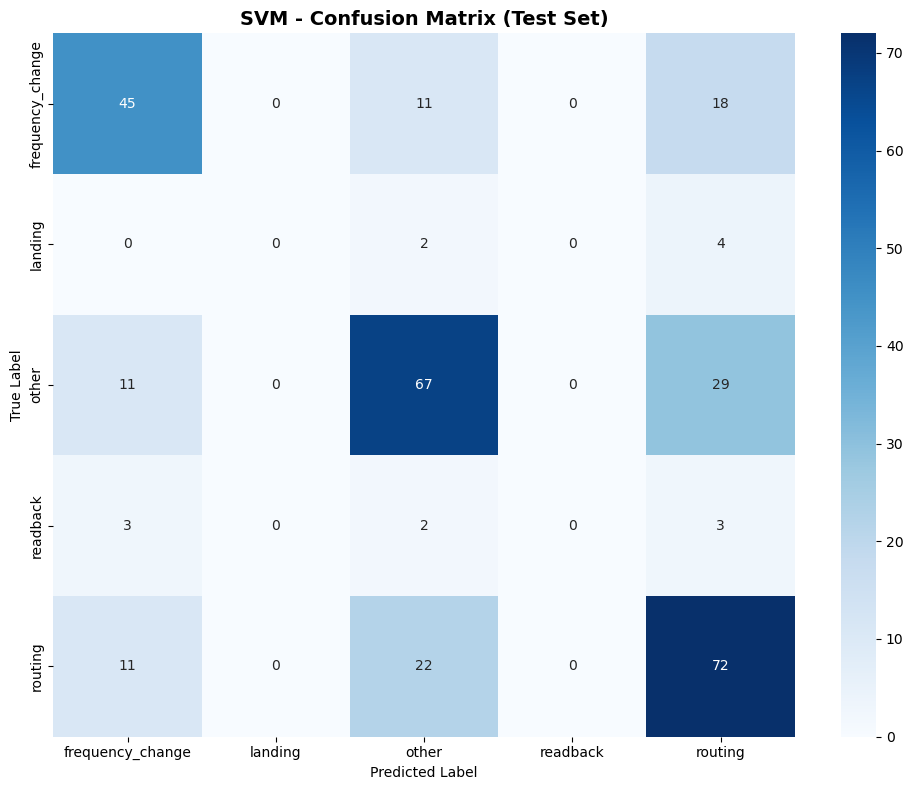

In [6]:
print("="*80)
print("SUPPORT VECTOR MACHINE (SVM)")
print("="*80)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
svm_model.fit(X_train_scaled, y_train)

y_pred_train_svm = svm_model.predict(X_train_scaled)
y_pred_val_svm = svm_model.predict(X_val_scaled)
y_pred_test_svm = svm_model.predict(X_test_scaled)

train_acc_svm = accuracy_score(y_train, y_pred_train_svm)
val_acc_svm = accuracy_score(y_val, y_pred_val_svm)
test_acc_svm = accuracy_score(y_test, y_pred_test_svm)

print(f"\nResultados SVM:")
print(f"   Train Accuracy: {train_acc_svm:.4f}")
print(f"   Val Accuracy:   {val_acc_svm:.4f}")
print(f"   Test Accuracy:  {test_acc_svm:.4f}")

print("\nClassification Report (Test):")
print(classification_report(
    y_test, y_pred_test_svm,
    labels=all_class_labels,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_svm = confusion_matrix(y_test, y_pred_test_svm, labels=all_class_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('SVM - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 6.2 Random Forest

RANDOM FOREST

Resultados Random Forest:
   Train Accuracy: 0.9635
   Val Accuracy:   0.5433
   Test Accuracy:  0.5400

Classification Report (Test):
                  precision    recall  f1-score   support

frequency_change       0.53      0.47      0.50        74
         landing       0.00      0.00      0.00         6
           other       0.55      0.55      0.55       107
        readback       0.00      0.00      0.00         8
         routing       0.54      0.65      0.59       105

        accuracy                           0.54       300
       macro avg       0.32      0.33      0.33       300
    weighted avg       0.51      0.54      0.53       300



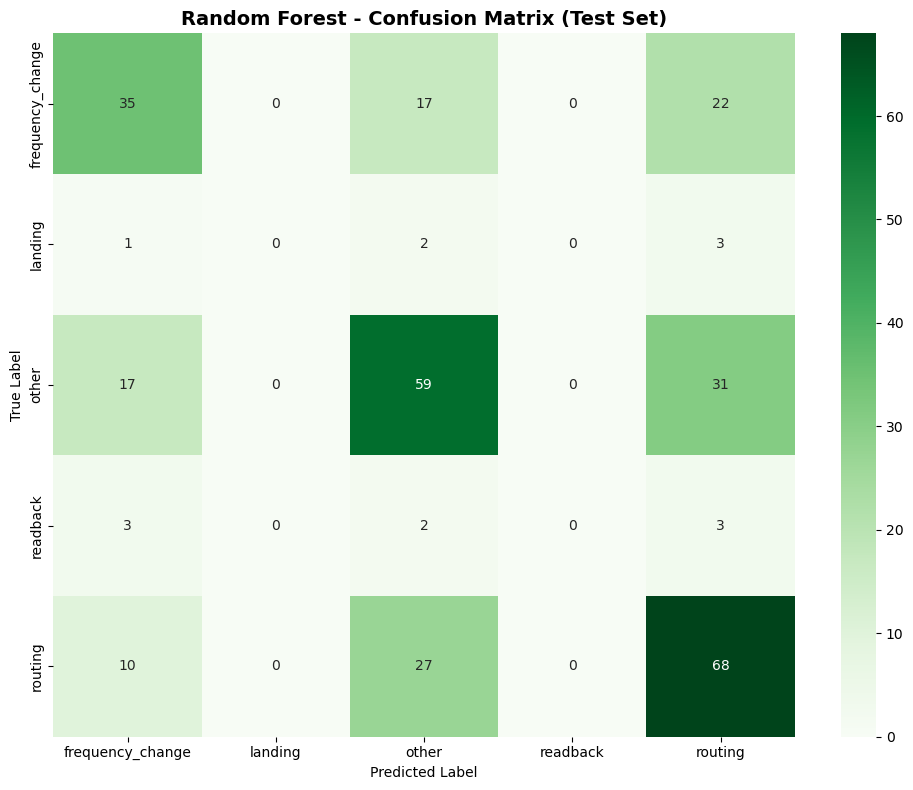


Top 10 Features más importantes:
1. Feature 9: 0.0449
2. Feature 21: 0.0371
3. Feature 14: 0.0285
4. Feature 37: 0.0282
5. Feature 12: 0.0241
6. Feature 8: 0.0240
7. Feature 10: 0.0232
8. Feature 27: 0.0221
9. Feature 18: 0.0213
10. Feature 30: 0.0210


In [7]:
print("="*80)
print("RANDOM FOREST")
print("="*80)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_train_rf = rf_model.predict(X_train_scaled)
y_pred_val_rf = rf_model.predict(X_val_scaled)
y_pred_test_rf = rf_model.predict(X_test_scaled)

train_acc_rf = accuracy_score(y_train, y_pred_train_rf)
val_acc_rf = accuracy_score(y_val, y_pred_val_rf)
test_acc_rf = accuracy_score(y_test, y_pred_test_rf)

print(f"\nResultados Random Forest:")
print(f"   Train Accuracy: {train_acc_rf:.4f}")
print(f"   Val Accuracy:   {val_acc_rf:.4f}")
print(f"   Test Accuracy:  {test_acc_rf:.4f}")

print("\nClassification Report (Test):")
print(classification_report(
    y_test, y_pred_test_rf,
    labels=all_class_labels,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_rf = confusion_matrix(y_test, y_pred_test_rf, labels=all_class_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Random Forest - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

feature_importance = rf_model.feature_importances_
print(f"\nTop 10 Features más importantes:")
top_indices = np.argsort(feature_importance)[-10:][::-1]
for i, idx in enumerate(top_indices, 1):
    print(f"{i}. Feature {idx}: {feature_importance[idx]:.4f}")

### 6.3 Comparación ML Clásico


COMPARACIÓN MACHINE LEARNING CLÁSICO
        Model  Train Acc  Val Acc  Test Acc  Overfitting
          SVM   0.820458 0.620000  0.613333     0.200458
Random Forest   0.963519 0.543333  0.540000     0.420186


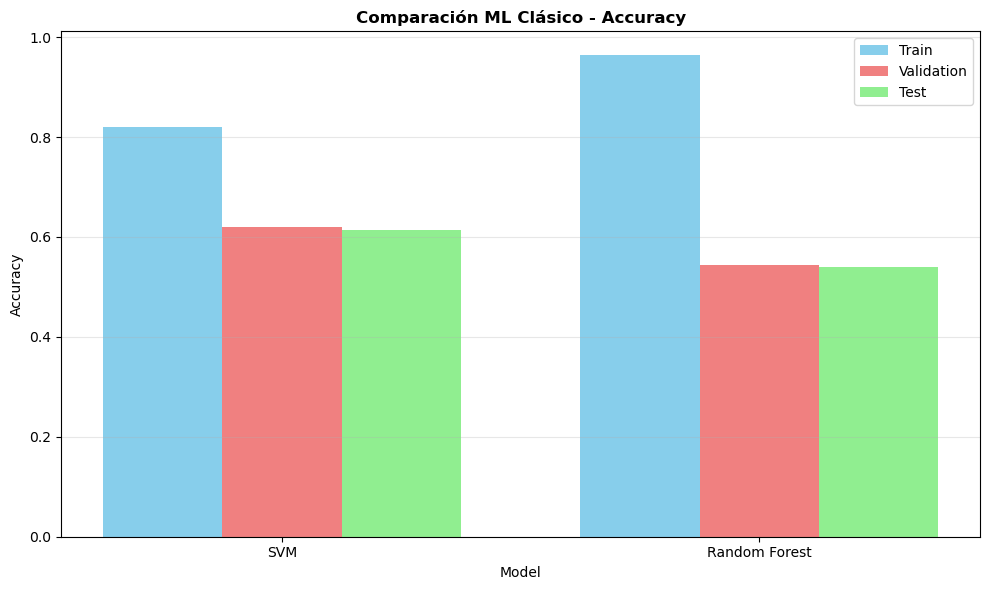

In [8]:
ml_results = pd.DataFrame({
    'Model': ['SVM', 'Random Forest'],
    'Train Acc': [train_acc_svm, train_acc_rf],
    'Val Acc': [val_acc_svm, val_acc_rf],
    'Test Acc': [test_acc_svm, test_acc_rf],
    'Overfitting': [
        train_acc_svm - val_acc_svm,
        train_acc_rf - val_acc_rf
    ]
})

print("\n" + "="*80)
print("COMPARACIÓN MACHINE LEARNING CLÁSICO")
print("="*80)
print(ml_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ml_results))
width = 0.25

ax.bar(x - width, ml_results['Train Acc'], width, label='Train', color='skyblue')
ax.bar(x, ml_results['Val Acc'], width, label='Validation', color='lightcoral')
ax.bar(x + width, ml_results['Test Acc'], width, label='Test', color='lightgreen')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Comparación ML Clásico - Accuracy', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ml_results['Model'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. DEEP LEARNING FROM SCRATCH - CNN 1D

Vamos a crear una CNN 1D para clasificación de audio desde cero.

### 7.1 Preparar Datos para PyTorch

In [9]:
X_train_tensor = torch.FloatTensor(X_train_scaled).unsqueeze(1)  # [batch, 1, features]
X_val_tensor = torch.FloatTensor(X_val_scaled).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled).unsqueeze(1)

y_train_tensor = torch.LongTensor(y_train)
y_val_tensor = torch.LongTensor(y_val)
y_test_tensor = torch.LongTensor(y_test)

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders creados:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

DataLoaders creados:
   Train batches: 44
   Val batches:   10
   Test batches:  10


### 7.2 Definir Arquitectura CNN 1D

In [10]:
class CNN1D_ATC(nn.Module):
    """
    CNN 1D para clasificación de audio ATC
    Arquitectura from scratch
    """
    def __init__(self, input_size, num_classes, dropout=0.5):
        super(CNN1D_ATC, self).__init__()
        
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)
        
        self.flatten_size = 256 * (input_size // 8)
        
        self.fc1 = nn.Linear(self.flatten_size, 512)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        
        return x

num_classes = len(label_encoder.classes_)
input_size = X_train_scaled.shape[1]

model_cnn = CNN1D_ATC(input_size=input_size, num_classes=num_classes, dropout=0.5)
model_cnn = model_cnn.to(device)

print(f"Modelo CNN 1D creado")
print(f"   Parámetros totales: {sum(p.numel() for p in model_cnn.parameters())}")
print(f"   Input size: {input_size}")
print(f"   Output classes: {num_classes}")

Modelo CNN 1D creado
   Parámetros totales: 1175045
   Input size: 60
   Output classes: 5


### 7.3 Función de Entrenamiento

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Entrena el modelo por una época
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    """
    Valida el modelo
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

print("Funciones de entrenamiento definidas")

Funciones de entrenamiento definidas


### 7.4 Entrenar CNN 1D

In [12]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
PATIENCE = 10  # Para early stopping

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0

print("Iniciando entrenamiento...\n")
print(f"Configuración:")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Device: {device}")
print("\n" + "="*80)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model_cnn, train_loader, criterion, optimizer, device)
    
    val_loss, val_acc = validate_epoch(model_cnn, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_cnn.state_dict(), str(NOTEBOOK_OUTPUT_DIR / 'best_cnn1d_model.pth'))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n️Early stopping triggered at epoch {epoch+1}")
            break

print("\n" + "="*80)
print("Entrenamiento completado")

Iniciando entrenamiento...

Configuración:
  Learning Rate: 0.001
  Epochs: 50
  Batch Size: 32
  Device: cpu

Epoch [1/50] Train Loss: 1.3193 | Train Acc: 0.4056 | Val Loss: 1.2225 | Val Acc: 0.4633
Epoch [2/50] Train Loss: 1.1962 | Train Acc: 0.4778 | Val Loss: 1.1235 | Val Acc: 0.5267
Epoch [3/50] Train Loss: 1.0952 | Train Acc: 0.5508 | Val Loss: 1.0917 | Val Acc: 0.5600
Epoch [4/50] Train Loss: 0.9519 | Train Acc: 0.6423 | Val Loss: 1.1356 | Val Acc: 0.5500
Epoch [5/50] Train Loss: 0.8716 | Train Acc: 0.6724 | Val Loss: 1.0812 | Val Acc: 0.5700
Epoch [6/50] Train Loss: 0.7847 | Train Acc: 0.7003 | Val Loss: 1.1355 | Val Acc: 0.5967
Epoch [7/50] Train Loss: 0.6800 | Train Acc: 0.7668 | Val Loss: 1.0876 | Val Acc: 0.6000
Epoch [8/50] Train Loss: 0.5856 | Train Acc: 0.8076 | Val Loss: 1.3950 | Val Acc: 0.5300
Epoch [9/50] Train Loss: 0.5513 | Train Acc: 0.8004 | Val Loss: 1.5820 | Val Acc: 0.5567
Epoch [10/50] Train Loss: 0.4725 | Train Acc: 0.8433 | Val Loss: 1.5417 | Val Acc: 0.573

### 7.5 Visualizar Curvas de Entrenamiento (CRÍTICO PARA EVALUACIÓN)

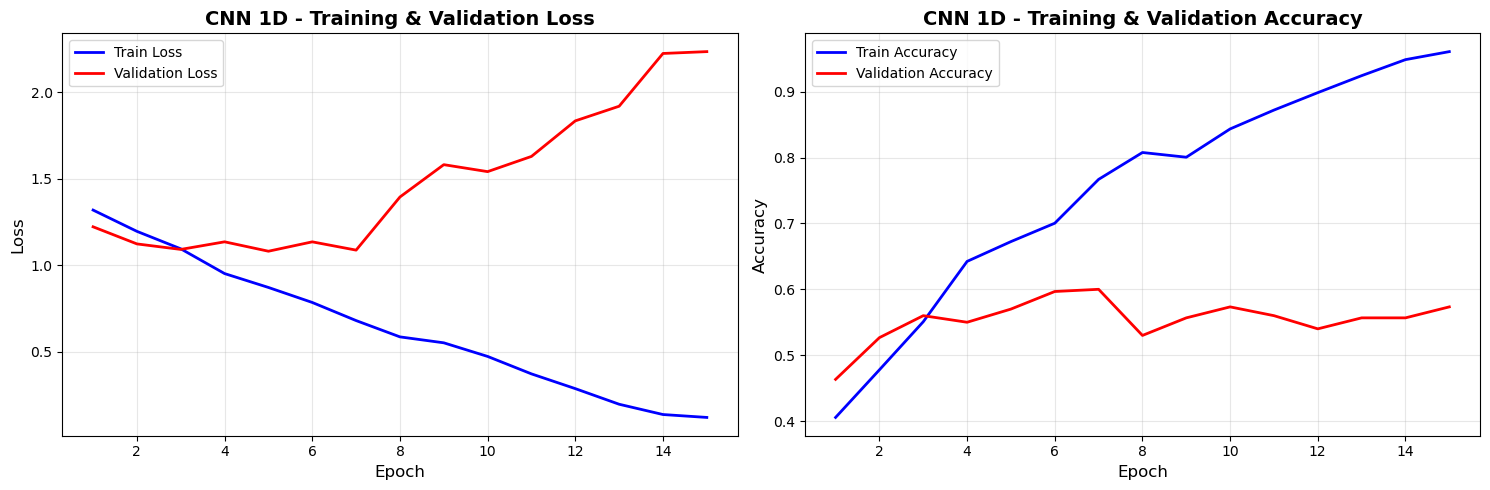


ANÁLISIS DE OVERFITTING:
   Final Train Accuracy: 0.9607
   Final Val Accuracy:   0.5733
   Gap (Train - Val):    0.3873
ALTO overfitting detectado


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('CNN 1D - Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('CNN 1D - Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
overfitting_gap = final_train_acc - final_val_acc

print("\nANÁLISIS DE OVERFITTING:")
print(f"   Final Train Accuracy: {final_train_acc:.4f}")
print(f"   Final Val Accuracy:   {final_val_acc:.4f}")
print(f"   Gap (Train - Val):    {overfitting_gap:.4f}")

if overfitting_gap > 0.1:
    print("ALTO overfitting detectado")
elif overfitting_gap > 0.05:
    print("MODERADO overfitting")
else:
    print("Overfitting BAJO - modelo generaliza bien")

### 7.6 Evaluar en Test Set

CNN 1D - Test Results:
   Test Loss:     1.0288
   Test Accuracy: 0.6133

Classification Report (Test):
                  precision    recall  f1-score   support

frequency_change       0.61      0.62      0.61        74
         landing       0.00      0.00      0.00         6
           other       0.60      0.73      0.66       107
        readback       0.00      0.00      0.00         8
         routing       0.65      0.57      0.61       105

        accuracy                           0.61       300
       macro avg       0.37      0.38      0.37       300
    weighted avg       0.59      0.61      0.60       300



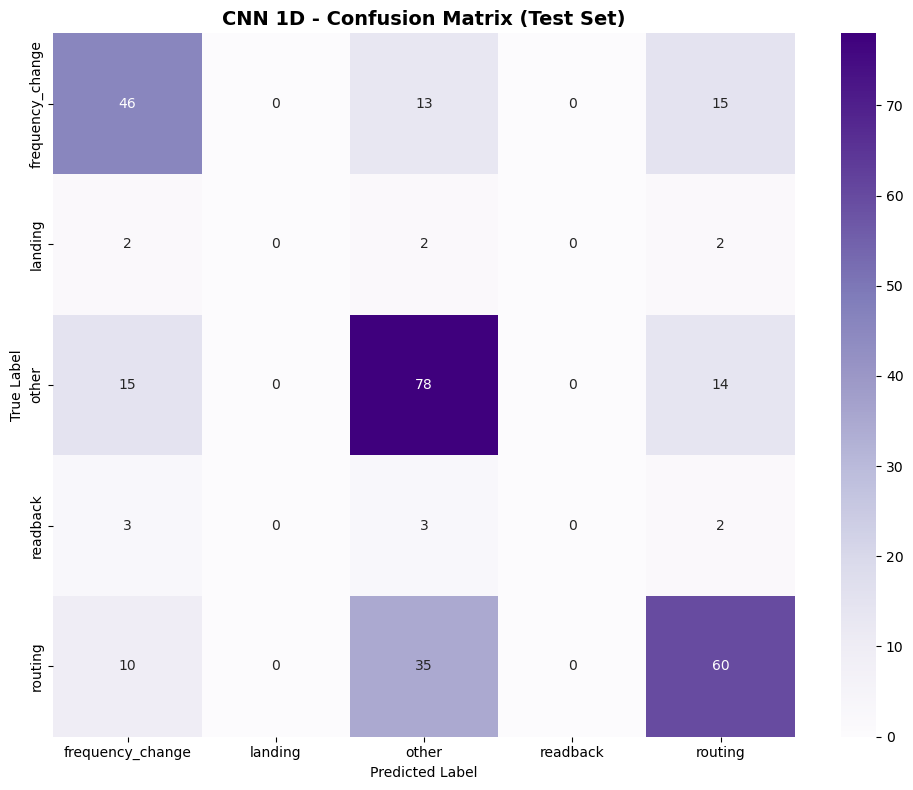

In [14]:
model_cnn.load_state_dict(torch.load(str(NOTEBOOK_OUTPUT_DIR / 'best_cnn1d_model.pth')))

test_loss, test_acc = validate_epoch(model_cnn, test_loader, criterion, device)

print(f"CNN 1D - Test Results:")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f}")

model_cnn.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_cnn(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("\nClassification Report (Test):")
print(classification_report(
    all_labels, all_preds,
    labels=all_class_labels,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_cnn = confusion_matrix(all_labels, all_preds, labels=all_class_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Purples', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('CNN 1D - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. COMPARACIÓN FINAL DE TODOS LOS MODELOS


 COMPARACIÓN FINAL - TODOS LOS MODELOS
        Model  Train Acc  Val Acc  Test Acc  Overfitting
          SVM   0.820458 0.620000  0.613333     0.200458
Random Forest   0.963519 0.543333  0.540000     0.420186
       CNN 1D   0.960658 0.573333  0.613333     0.387325


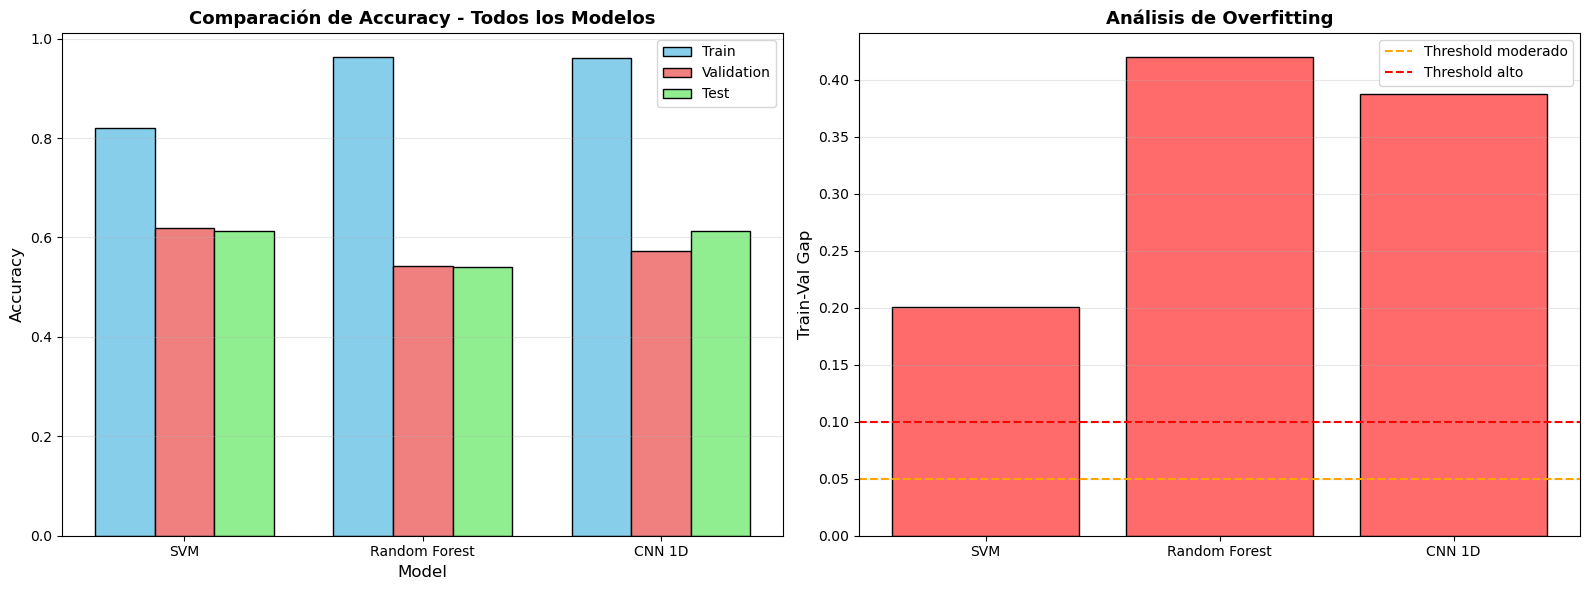

In [15]:
results_comparison = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'CNN 1D'],
    'Train Acc': [train_acc_svm, train_acc_rf, final_train_acc],
    'Val Acc': [val_acc_svm, val_acc_rf, final_val_acc],
    'Test Acc': [test_acc_svm, test_acc_rf, test_acc],
    'Overfitting': [
        train_acc_svm - val_acc_svm,
        train_acc_rf - val_acc_rf,
        overfitting_gap
    ]
})

print("\n" + "="*80)
print(" COMPARACIÓN FINAL - TODOS LOS MODELOS")
print("="*80)
print(results_comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(results_comparison))
width = 0.25

axes[0].bar(x - width, results_comparison['Train Acc'], width, label='Train', color='skyblue', edgecolor='black')
axes[0].bar(x, results_comparison['Val Acc'], width, label='Validation', color='lightcoral', edgecolor='black')
axes[0].bar(x + width, results_comparison['Test Acc'], width, label='Test', color='lightgreen', edgecolor='black')

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Comparación de Accuracy - Todos los Modelos', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_comparison['Model'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(results_comparison['Model'], results_comparison['Overfitting'], 
            color=['#FF6B6B' if x > 0.1 else '#FFA07A' if x > 0.05 else '#90EE90' 
                   for x in results_comparison['Overfitting']], edgecolor='black')
axes[1].set_ylabel('Train-Val Gap', fontsize=12)
axes[1].set_title('Análisis de Overfitting', fontsize=13, fontweight='bold')
axes[1].axhline(y=0.05, color='orange', linestyle='--', label='Threshold moderado')
axes[1].axhline(y=0.1, color='red', linestyle='--', label='Threshold alto')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. CONCLUSIONES CRÍTICAS

**IMPORTANTE:** Análisis crítico de los resultados (requerido por las pautas)

In [16]:
print("="*80)
print(" CONCLUSIONES DEL PROYECTO - PARTE 2")
print("="*80)

best_model_idx = results_comparison['Test Acc'].idxmax()
best_model = results_comparison.loc[best_model_idx, 'Model']
best_test_acc = results_comparison.loc[best_model_idx, 'Test Acc']
best_overfitting = results_comparison.loc[best_model_idx, 'Overfitting']

print(f"\n1 MEJOR MODELO POR ACCURACY:")
print(f"   Modelo: {best_model}")
print(f"   Test Accuracy: {best_test_acc:.4f}")
print(f"   Overfitting: {best_overfitting:.4f}")

print(f"\n2 ANÁLISIS DE GENERALIZACIÓN:")
if best_overfitting > 0.1:
    print(f"   ️ El modelo {best_model} tiene ALTO overfitting")
    print(f"   → No recomendado para producción sin regularización adicional")
    print(f"   → Considerar: más dropout, data augmentation, early stopping más agresivo")
elif best_overfitting > 0.05:
    print(f"    El modelo {best_model} tiene overfitting MODERADO")
    print(f"   → Aceptable, pero monitorear en producción")
    print(f"   → Considerar validation cross-fold adicional")
else:
    print(f"    El modelo {best_model} generaliza MUY BIEN")
    print(f"   → Candidato FUERTE para despliegue en producción")

print(f"\n3 COMPARACIÓN ML CLÁSICO vs DL:")
ml_avg = (test_acc_svm + test_acc_rf) / 2
dl_acc = test_acc

if dl_acc > ml_avg:
    improvement = ((dl_acc - ml_avg) / ml_avg) * 100
    print(f"    DL supera a ML clásico en {improvement:.2f}%")
    print(f"   → El overhead computacional de DL está JUSTIFICADO")
else:
    print(f"    ML clásico tiene desempeño competitivo")
    print(f"   → Considerar usar ML para despliegue (más rápido, menos recursos)")

print(f"\n4 PRÓXIMOS PASOS:")
print(f"   → Transfer Learning (Wav2Vec 2.0, Whisper) en Notebook 3")
print(f"   → Análisis de texto (transcripciones) en Notebook 4")
print(f"   → Comparación con APIs comerciales en Notebook 5")

print("\n" + "="*80)

 CONCLUSIONES DEL PROYECTO - PARTE 2

1 MEJOR MODELO POR ACCURACY:
   Modelo: SVM
   Test Accuracy: 0.6133
   Overfitting: 0.2005

2 ANÁLISIS DE GENERALIZACIÓN:
   ️ El modelo SVM tiene ALTO overfitting
   → No recomendado para producción sin regularización adicional
   → Considerar: más dropout, data augmentation, early stopping más agresivo

3 COMPARACIÓN ML CLÁSICO vs DL:
    DL supera a ML clásico en 6.36%
   → El overhead computacional de DL está JUSTIFICADO

4 PRÓXIMOS PASOS:
   → Transfer Learning (Wav2Vec 2.0, Whisper) en Notebook 3
   → Análisis de texto (transcripciones) en Notebook 4
   → Comparación con APIs comerciales en Notebook 5



## 10. Guardar Resultados

In [17]:
results_comparison.to_csv(NOTEBOOK_OUTPUT_DIR / 'model_comparison_results.csv', index=False)

history_df = pd.DataFrame(history)
history_df.to_csv(NOTEBOOK_OUTPUT_DIR / 'cnn_training_history.csv', index=False)

with open(NOTEBOOK_OUTPUT_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

with open(NOTEBOOK_OUTPUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Resultados guardados:")
print("   - model_comparison_results.csv")
print("   - cnn_training_history.csv")
print("   - best_cnn1d_model.pth")
print("   - label_encoder.pkl")
print("   - scaler.pkl")

Resultados guardados:
   - model_comparison_results.csv
   - cnn_training_history.csv
   - best_cnn1d_model.pth
   - label_encoder.pkl
   - scaler.pkl
